In [74]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

# Cinética de Procesos (Sesión 02)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# Tarea Ejercicio 1:

## Método integral

In [75]:
t  = np.array([0, 5,  10, 15,   20,   30, 40, 60, 90, 120, 150]) # [min]
cA = np.array([0, 4, 7.5, 10, 15.5, 24.5, 31, 39, 44,  45,  45]) * 1e-3 # [mol/l]
df = pd.DataFrame({"t": t, 'cA': cA})
display(df)

,t,cA
0,0,0.0000
1,5,0.0040
2,10,0.0075
3,15,0.0100
4,20,0.0155
5,30,0.0245
6,40,0.0310
7,60,0.0390
8,90,0.0440
9,120,0.0450


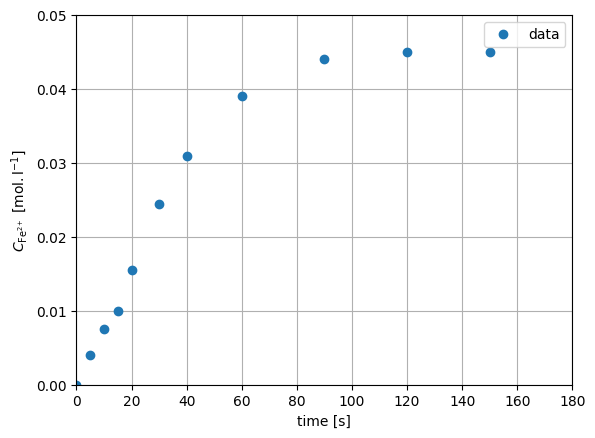

In [76]:
fig, ax = plt.subplots()
# experimental data
ax.plot(t, cA, ls='', marker='o', label='data')
ax.set(
    xlabel="time [s]",
    ylabel=r"$C_{\mathrm{Fe^{2+}}}$ [$\mathrm{mol.l^{-1}}$]",
    xlim = (0, 180),
    ylim = (0, 0.05)
)
ax.grid()
ax.legend()
plt.show()

### Transformando datos

In [77]:
cAt = cA[-1] - cA

In [78]:
def rate_law_0(t, k, cA0):
    return cA0 - k*t

cA0 = cAt[0]
eps = 1e-8
# ajuste de la ley de orden zero (mínimos cuadrados)
params, cov = curve_fit(
    f=rate_law_0, 
    xdata=t[:-3], 
    ydata=cAt[:-3], 
    bounds=[(-np.inf, (cA0-eps)), (np.inf, (cA0+eps))]
)
k0 = params[0]
print(f"k = {k0:.2e} [mol/(l.s)]")

k = 7.11e-04 [mol/(l.s)]


In [79]:
def rate_law_1(t, k, cA0):
    return cA0 * np.exp(-k*t)

cA0 = cAt[0]
eps = 1e-8
# ajuste de la ley de orden zero (mínimos cuadrados)
params, cov = curve_fit(
    f=rate_law_1, 
    xdata=t[:-2], 
    ydata=cAt[:-2], 
    bounds=[(0, (cA0-eps)), (np.inf, (cA0+eps))]
)
k1 = params[0]
print(f"k = {k1:.2e} [mol/(l.s)]")

k = 2.59e-02 [mol/(l.s)]


In [80]:
def rate_law_2(t, k, cA0):
    return 1 / (k*t + 1/cA0)

cA0 = cAt[0]
eps = 1e-8
# ajuste de la ley de orden zero (mínimos cuadrados)
params, cov = curve_fit(
    f=rate_law_2, 
    xdata=t[:-2], 
    ydata=cAt[:-2], 
    bounds=[(0, (cA0-eps)), (np.inf, (cA0+eps))]
)
k2 = params[0]
print(f"k = {k2:.2e} [mol/(l.s)]")

k = 8.65e-01 [mol/(l.s)]


In [81]:
# define the rate law:
def rate_law(t, cA, k, n):
    return -k*np.power(cA,n)

# solve the ODE
def solve_rate_law(t, k, n):
    sol = solve_ivp(
        fun = rate_law,
        t_span = [t[0], t[-1]],
        y0 = [cAt[0]],
        args=(k, n),
        dense_output=True
    )
    return sol.sol(t)[0]

# Fit the parameters
eps = 1e-8
popt, pcov = curve_fit(
    f = lambda t, k, n: solve_rate_law(t, k, n),
    xdata = t[:-2],
    ydata = cAt[:-2],
    p0=(5e-3, 0.6),
    bounds = ((0,0),(np.inf,10))
)
k, n = popt[0], popt[1]
print(f"k = {k:.2e} [###/s]")
print(f"n = {n:.2f}")

/tmp/ipykernel_112961/3350710416.py:3: RuntimeWarning: invalid value encountered in power
  return -k*np.power(cA,n)


k = 3.65e-03 [###/s]
n = 0.45


/tmp/ipykernel_112961/3350710416.py:3: RuntimeWarning: invalid value encountered in power
  return -k*np.power(cA,n)


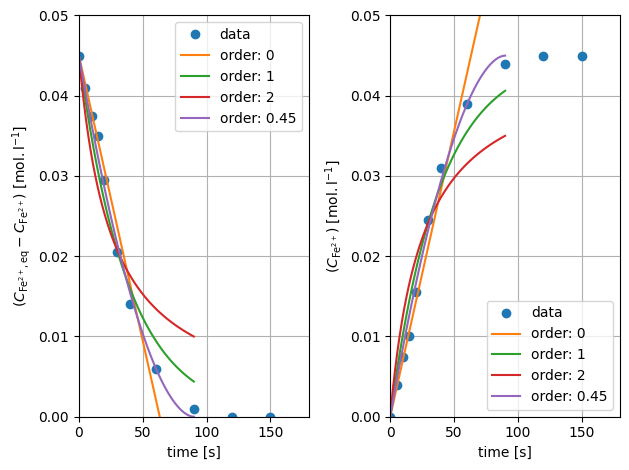

In [82]:
fig, (ax0, ax1) = plt.subplots(ncols=2)

# Transformed data (assuming equilibrium has been reached after long reaction times)
ax0.plot(t, cAt, ls='', marker='o', label='data')
tt = np.linspace(0, 90, 50)
ax0.plot(tt, rate_law_0(tt, k0, cAt[0]), label='order: 0')
ax0.plot(tt, rate_law_1(tt, k1, cAt[0]), label='order: 1')
ax0.plot(tt, rate_law_2(tt, k2, cAt[0]), label='order: 2')
ax0.plot(tt, solve_rate_law(tt, *popt), label=f'order: {n:.2f}')
ax0.set_ylabel(r"$(C_{\mathrm{Fe^{2+},eq}} - C_{\mathrm{Fe^{2+}}})$ [$\mathrm{mol.l^{-1}}$]")

# "raw" data vs models
ax1.plot(t, cA, ls='', marker='o', label='data')
tt = np.linspace(0, 90, 50)
ax1.plot(tt, cAt[0]-rate_law_0(tt, k0, cAt[0]), label='order: 0')
ax1.plot(tt, cAt[0]-rate_law_1(tt, k1, cAt[0]), label='order: 1')
ax1.plot(tt, cAt[0]-rate_law_2(tt, k2, cAt[0]), label='order: 2')
ax1.plot(tt, cAt[0]-solve_rate_law(tt, *popt), label=f'order: {n:.2f}')
ax1.set_ylabel(r"$(C_{\mathrm{Fe^{2+}}})$ [$\mathrm{mol.l^{-1}}$]")

for ax in [ax0, ax1]:
    ax.set(
        xlabel="time [s]",
        xlim = (0, 180),
        ylim = (0, 0.05)
    )
    ax.grid()
    ax.legend()
fig.tight_layout()
plt.show()

# Tarea Ejercicio 2

In [83]:
def rate_law_n(t, k, cA0, n):
    rhs = np.power(cA0, 1-n)  + (n-1)*k*t
    return np.power(rhs, 1/(1-n))

/tmp/ipykernel_112961/2924480356.py:3: RuntimeWarning: invalid value encountered in power
  return np.power(rhs, 1/(1-n))


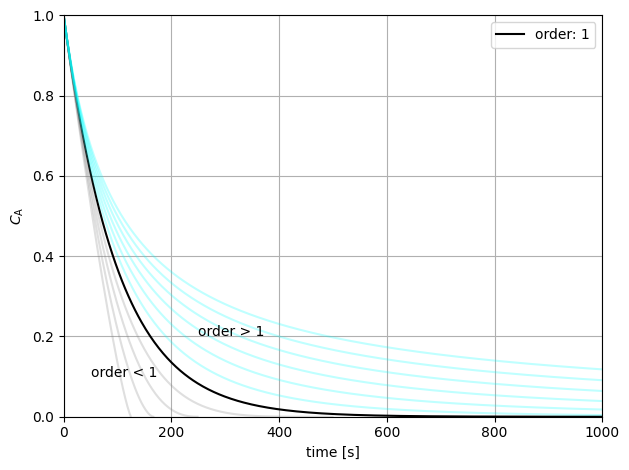

In [88]:
cA0 = 1
k = 1e-2
dn = 0.2
nmax = 2
tt = np.linspace(0, 1000, 500)
fig, ax = plt.subplots()
ax.plot(tt, rate_law_1(tt, k, cA0), color='k', label='order: 1')
# rate laws up to order 1
for n in np.arange(dn, 1, dn):
    ax.plot(tt, rate_law_n(tt, k, cA0, n), color='gray', alpha=0.25)
# rate laws above order 1
for n in np.arange(1+dn, nmax+dn, dn):
    ax.plot(tt, rate_law_n(tt, k, cA0, n), color='cyan', alpha=0.25)
ax.set(
        xlabel="time [s]",
        ylabel=r"$C_{\mathrm{A}}$",
        xlim = (0, 1000),
        ylim = (0, 1)
)
ax.annotate("order > 1", xy=(250, 0.2))
ax.annotate("order < 1", xy=(50, 0.1))
ax.grid()
ax.legend()
fig.tight_layout()
plt.show()